<h1 align = "center">Detected Exoplanets</h1>

Rank | Name | Input Catalog | Orbital Period | Exoplanet Radius | Orbital Distance | Habitable Zone? |
| :- | :- | :- | -: | -: |-: | -: |
|Max Radius| BD-14 3065 b | TIC 293607057 | 4.29 d| 20.44 R🜨| 0.058 AU | too hot|
|Min Radius| L 98-59 b | TIC 307210830 | 2.25 d| 0.91 R🜨| 0.022 AU  |  too hot |
|Max Period| TOI-1836 b | TIC 207468071 | 20.38 d| 8.96 R🜨| 0.158 AU | too hot |
|Min Period| L 98-59 b | TIC 307210830 | 2.25 d| 0.91 R🜨| 0.022 AU  |  too hot |
|Max Exoplanets| TOI-270 b | TIC 259377017 | 3.36 d| 1.25 R🜨| 0.031 AU  |  too hot |
|Max Exoplanets| TOI-270 c | TIC 259377017 | 5.66 d| 2.34 R🜨| 0.044 AU | too hot |
|Max Exoplanets| TOI-270 d | TIC 259377017 | 11.38 d| 1.94 R🜨| 0.071 AU | too hot |

<center>gas giant > 6 R🜨 > neptunian > 4 R🜨 > sub-neptune > 2 R🜨 > super-earth > 1.5 R🜨 > terrestrial</center>

In [1]:
%matplotlib widget
import statistics
import matplotlib.pyplot as plt
import lightkurve as lk
import numpy as np
from scipy import stats
from scipy.optimize import least_squares
from astropy import units as u
from astropy import constants as const
from astroquery.mast import Catalogs
import batman

In [2]:
render_plots = True

In [3]:
input_catalog = input('input catalog: ')
split = input_catalog.split(' ')
telescope = split[0]

try:
    star = Catalogs.query_object(input_catalog, catalog = 'TIC')
except:
    print('MAST import error: try again')

input catalog:  TIC 307210830


In [4]:
def import_tess(input_catalog, author):    
    all_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short')
    print('all data:')
    print(all_data)
    
    sectors_list = []
    for sector in all_data.table:
        sectors_list.append(int(sector['sequence_number']))

    all_years = []
    for each in all_data:
        all_years.append(each.year.item())
    yr_max_i = np.max(range(len(all_years)))
    yr_max = (all_years[yr_max_i])
    yr_min = (all_years[0])
    yr_range = yr_max - yr_min

    if yr_range > 5:
        yr_count = np.bincount(all_years)
        yr_mode = round(np.argmax(yr_count))
        yr_median = round(np.median(all_years))

        if np.max(yr_count) > 5:
            year_mask = (all_data.table['year'] >= yr_mode - 2) & (all_data.table['year'] <= yr_mode + 2)
        else:
            year_mask = (all_data.table['year'] >= yr_median - 2) & (all_data.table['year'] <= yr_median + 2)
                
        selected_data = all_data[year_mask]
        stitch_me = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list)[year_mask].download_all()
    else:
        selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
        stitch_me = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors_list).download_all()
        
    print('\nselected data:')
    print(selected_data)        
    return all_data, sectors_list, selected_data, stitch_me

def import_kepler(input_catalog, author):    
    all_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short')
    print('all data:')
    print(all_data)
    
    quarters_list = []
    for quarter in all_data.table:
        quarters_list.append(int(quarter['mission'].split(' ')[2]))

    all_years = []
    for each in all_data:
        all_years.append(each.year.item())
    yr_max_i = np.max(range(len(all_years)))
    yr_max = (all_years[yr_max_i])
    yr_min = (all_years[0])
    yr_range = yr_max - yr_min

    if yr_range > 5:
        yr_count = np.bincount(all_years)
        yr_mode = round(np.argmax(yr_count))
        yr_median = round(np.median(all_years))

        if np.max(yr_count) > 5:
            year_mask = (all_data.table['year'] >= yr_mode - 1) & (all_data.table['year'] <= yr_mode + 1)
        else:
            year_mask = (all_data.table['year'] >= yr_median - 1) & (all_data.table['year'] <= yr_median + 1)
                
        selected_data = all_data[year_mask]
        stitch_me = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list)[year_mask].download_all()
    else:
        selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', limit = 5)
        stitch_me = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters_list).download_all()
        
    print('\nselected data:')
    print(selected_data)
    return all_data, quarters_list, selected_data, stitch_me

if telescope == 'TIC':
    author = 'SPOC'
    all_data, sectors, selected_data, stitch_me = import_tess(input_catalog, author)
if telescope == 'KIC':
    author = 'Kepler'
    all_data, quarters, selected_data, stitch_me = import_kepler(input_catalog, author)

all data:
SearchResult containing 27 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 02 2018   SPOC     120   307210830      0.0
  1 TESS Sector 05 2018   SPOC     120   307210830      0.0
  2 TESS Sector 08 2019   SPOC     120   307210830      0.0
  3 TESS Sector 09 2019   SPOC     120   307210830      0.0
  4 TESS Sector 10 2019   SPOC     120   307210830      0.0
  5 TESS Sector 11 2019   SPOC     120   307210830      0.0
  6 TESS Sector 12 2019   SPOC     120   307210830      0.0
  7 TESS Sector 28 2020   SPOC     120   307210830      0.0
  8 TESS Sector 29 2020   SPOC     120   307210830      0.0
  9 TESS Sector 32 2020   SPOC     120   307210830      0.0
 10 TESS Sector 39 2021   SPOC     120   307210830      0.0
 11 TESS Sector 37 2021   SPOC     120   307210830      0.0
 12 TESS Sector 38 2021   SPOC     120   307210

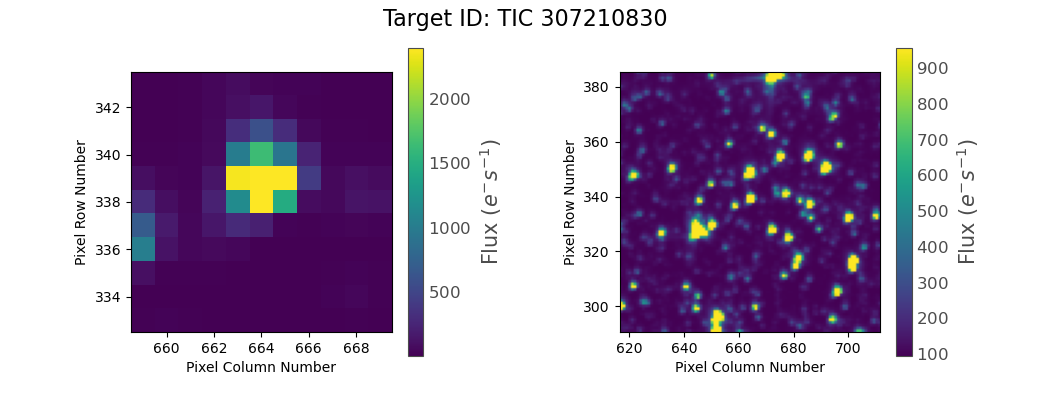

In [29]:
if render_plots == True:
    if telescope == 'TIC':
        fig, (ax1, ax2) = plt.subplots(nrows = 1 ,ncols = 2, figsize = (10.5, 4))
        fig.suptitle(f'Target ID: {input_catalog}', fontsize = 16)
        fig.subplots_adjust(wspace = .5)
        
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', sector = sectors[0]).download()
        px_file.plot(ax = ax1, title = '')
        
        ff_file = lk.search_tesscut(input_catalog, sector = sectors[0]).download(cutout_size = 95)
        ff_file.plot(ax = ax2, title = '')
        
    if telescope == 'KIC':
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = 'short', quarter = quarters[0]).download()
        px_file.plot()
        plt.title(f'Target ID: {input_catalog}', fontsize = 16)

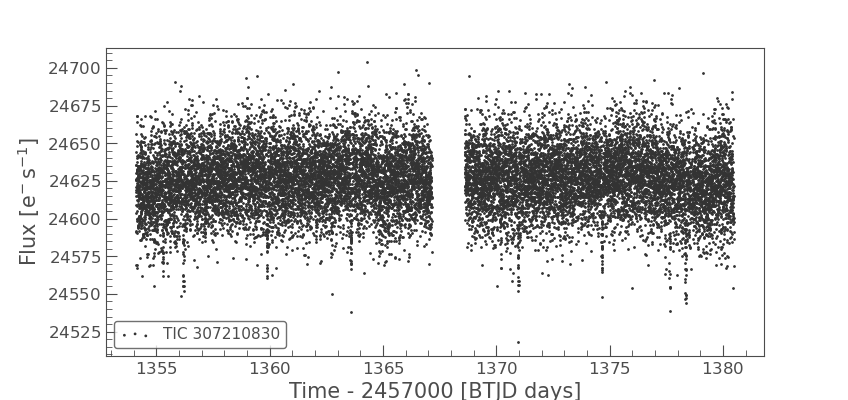

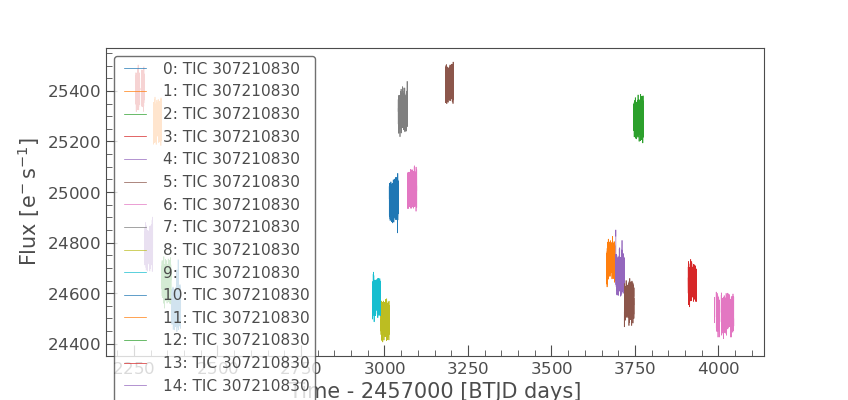

In [6]:
if telescope == 'TIC':
    ts_first = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', sector = sectors[0], limit = 1).download()
    if len(sectors) > 1:
        bls_me = stitch_me.stitch().remove_nans().flatten()
    else:
        ts_first.scatter()
        bls_me = ts_first.remove_nans().flatten()

if telescope == 'KIC':
    ts_first = lk.search_lightcurve(input_catalog, author = author, exptime = 'short', quarter = quarters[0], limit = 1).download()
    if len(quarters) > 1:
        bls_me = stitch_me.stitch().remove_nans().flatten()
    else:
        ts_first.scatter()
        bls_me = ts_first.remove_nans().flatten()

if render_plots == True:
    ts_first.scatter()
    stitch_me.plot()

In [15]:
h_binned = bls_me.bin(30/60/24)
min_period = 1
max_period = 14

time_series = [bls_me]
cycle = 0
selected_periods = []
exoplanets = []
periods = []
durations = []
transit_times = []

`period` contains 316110 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


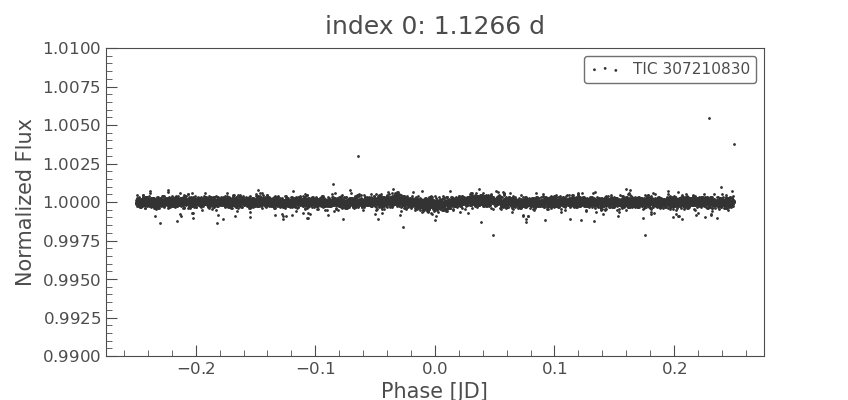

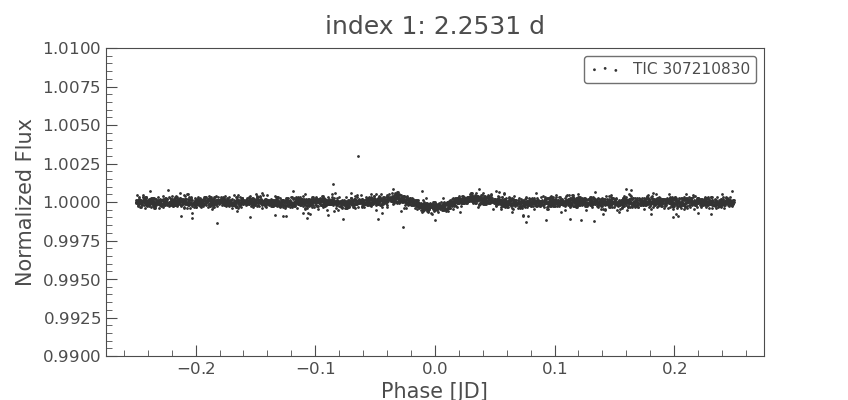

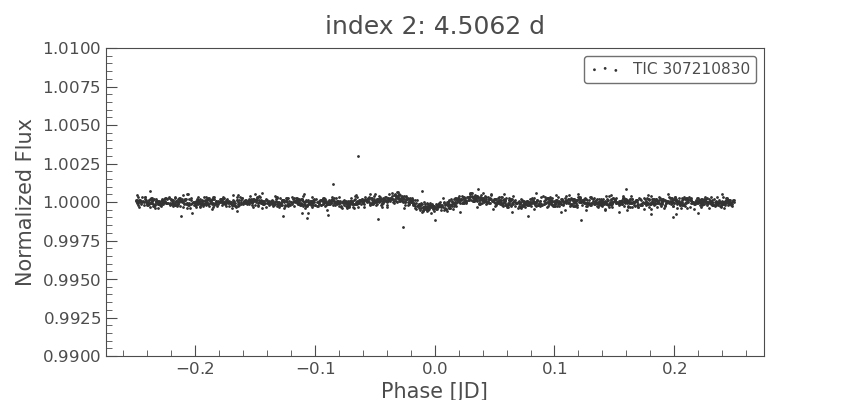

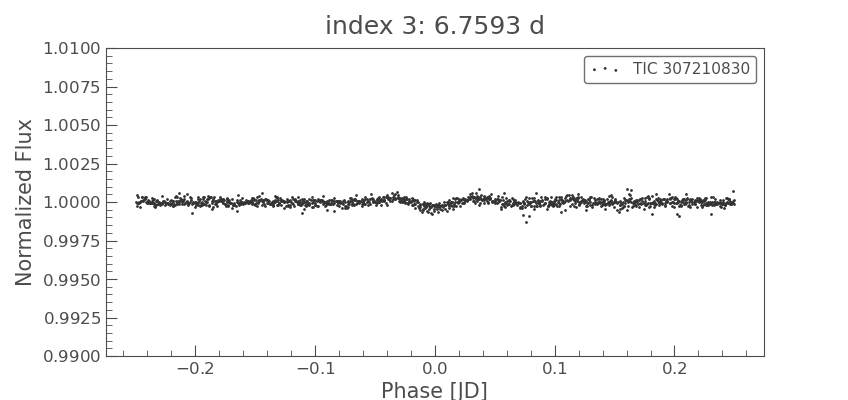

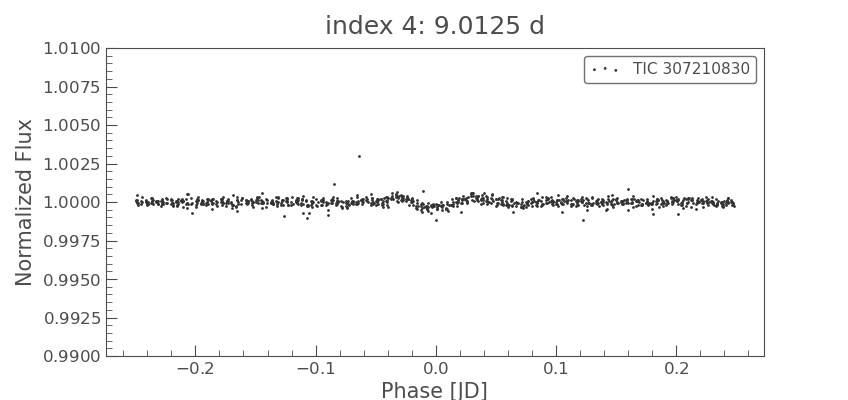

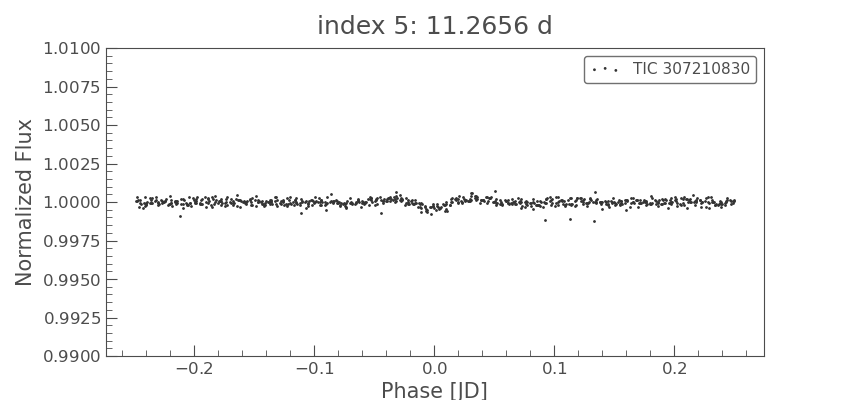

In [20]:
def initial_bls(ts, min_period, max_period):
    search_duration = np.linspace(.05, .3, 10)
    search_period = np.logspace(np.log10(min_period), np.log10(max_period), 5000) 
    initial_periodogram = ts.to_periodogram(method = 'bls', period = search_period, duration = search_duration, frequency_factor = 1000)
    initial_period = initial_periodogram.period_at_max_power
    initial_duration = initial_periodogram.duration_at_max_power  
    return initial_periodogram, initial_period, initial_duration
    
def refine_bls(ts, prev_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(prev_period.value - .1, prev_period.value + .1, 5000)
    refined_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    refined_period = refined_periodogram.period_at_max_power
    refined_duration = refined_periodogram.duration_at_max_power
    refined_time = refined_periodogram.transit_time_at_max_power
    return refined_periodogram, refined_period, refined_duration, refined_time

def plot_harmonics(refined_period, min_period, max_period, h_binned):
    harmonics = [refined_period.value]
    i = 2
    while i <= 5:
        harmonics_divide = refined_period.value/i
        harmonics_multiply = refined_period.value*i
        if harmonics_divide >= min_period:
            harmonics.append(harmonics_divide)
        if harmonics_multiply <= max_period:
            harmonics.append(harmonics_multiply)
        i += 1 
    harmonics.sort()
    
    for each in harmonics:
        folded = h_binned.fold(period = each, epoch_time = refined_time)
        transit = np.logical_and((folded.phase.value > -0.25), (folded.phase.value < 0.25))
        lim_folded = folded[transit]    
        lim_folded.scatter(title = f'index {harmonics.index(each)}: {round(each*u.day,4)}')
        plt.ylim(0.99,1.01)
    return harmonics

initial_periodogram, initial_period, initial_duration = initial_bls(time_series[-1], min_period, max_period)
refined_periodogram, refined_period, refined_duration, refined_time = refine_bls(time_series[-1], initial_period, initial_duration)
harmonics = plot_harmonics(refined_period, min_period, max_period, h_binned)

if cycle == 0:
    first_periodogram = initial_periodogram
cycle += 1

harmonics index:  1


`period` contains 421608 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


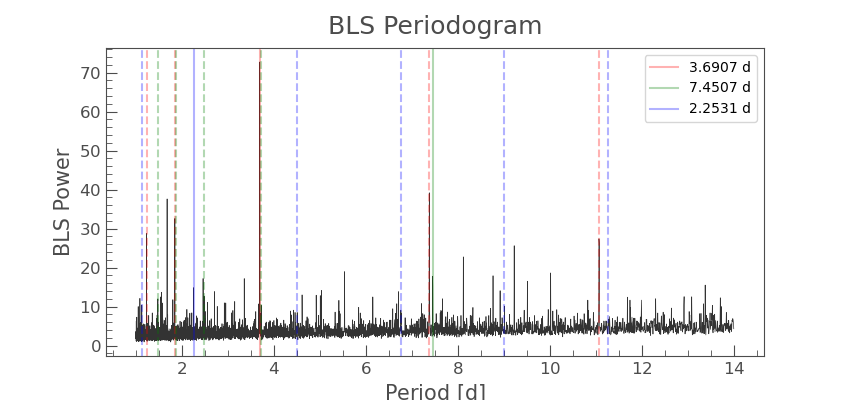

In [21]:
def mask_ts(time_series, ts, selected_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(selected_period - .1, selected_period + .1, 5000)
    final_periodogram = ts.to_periodogram(method = 'bls', period = period, duration = duration)
    final_period = final_periodogram.period_at_max_power
    final_duration = final_periodogram.duration_at_max_power
    final_time = final_periodogram.transit_time_at_max_power
    
    mask = final_periodogram.get_transit_mask(period = final_period, transit_time = final_time, duration = final_duration*2)
    masked_ts = ts[~mask]
    time_series.append(masked_ts)
    return time_series, masked_ts, final_period, final_duration, final_time

def plot_periodogram(first_periodogram, selected_periods, min_period, max_period):
    first_periodogram.plot(title = 'BLS Periodogram', label = '_nolegend_')
    
    i = 0
    while i < len(selected_periods):
        if i == 0:
            color = 'red'
        if i == 1:
            color = 'green'
        if i == 2:
            color = 'blue'
        if i == 3:
            color = 'orange'
        if i == 4:
            color = 'purple'
        plt.axvline(selected_periods[i], color = color, alpha = .3)

        labels = []
        for each in selected_periods:
            labels.append(round(each,4)*u.day)
        plt.legend(labels)
        
        x = 2
        while x <= 5:
            harmonics_divide = selected_periods[i]/x
            harmonics_multiply = selected_periods[i]*x
            if harmonics_divide >= min_period:
                plt.axvline(harmonics_divide, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            if harmonics_multiply <= max_period:
                plt.axvline(harmonics_multiply, color = color, linestyle = '--', alpha = .3, label = '_nolegend_')
            x += 1 
        i += 1

plt.close()
transit_period = input('harmonics index: ')
if transit_period.lower() != 'skip':
    transit_period = int(transit_period)
    for each in harmonics:
        if each == harmonics[transit_period]:
            selected_periods.append(each)

    time_series, masked_ts, final_period, final_duration, final_time = mask_ts(time_series, time_series[-1], selected_periods[-1], refined_duration)
    exoplanets.append({'period': final_period, 'duration': final_duration, 't0': final_time}) 
    periods.append(final_period.value)
    durations.append(final_duration.value)
    transit_times.append(final_time.value)
    plot_periodogram(first_periodogram, selected_periods, min_period, max_period)
else:   
    print('run previous cell')

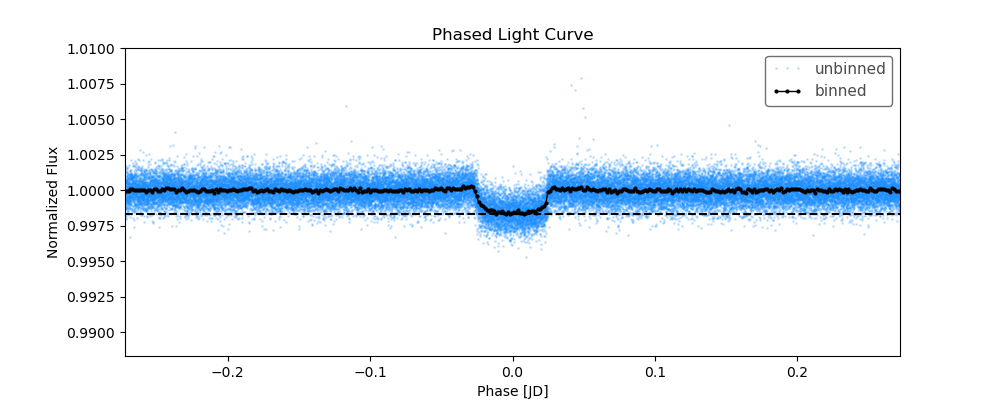

Radius:
1.3993 earthRad
0.1248 jupiterRad


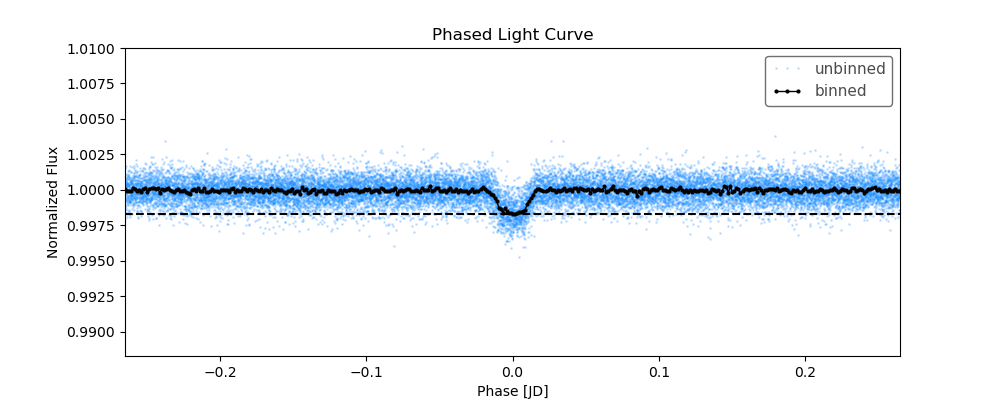

Radius:
1.4156 earthRad
0.1263 jupiterRad


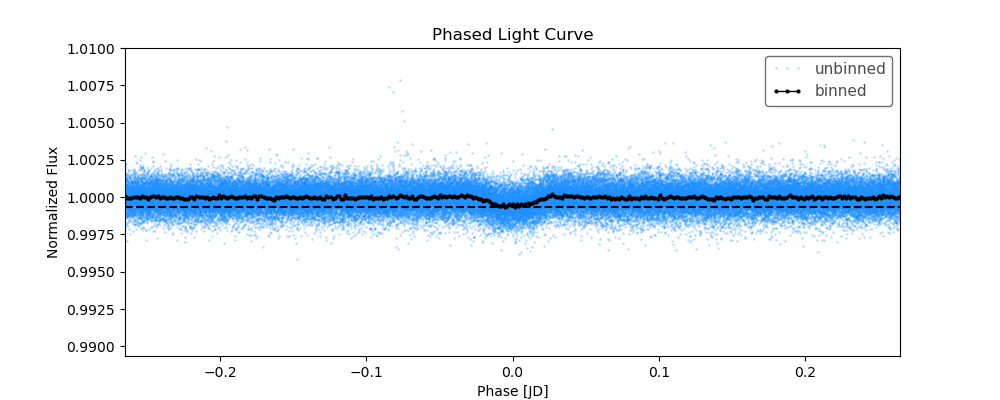

Radius:
0.8711 earthRad
0.0777 jupiterRad


In [23]:
def clean_data(mission, bls_me):
    transit_mask = bls_me.create_transit_mask(
                period = periods, 
                transit_time = transit_times, 
                duration = durations
            )
    if len(mission) > 1:
        fold_me = stitch_me.stitch().remove_nans().flatten(mask = transit_mask)
    else:
        fold_me = ts_first.remove_nans().flatten(mask = transit_mask)
    return fold_me

def plot_light_curve(fold_me, period, t0, duration):
    phased_lc = fold_me.fold(period = period, epoch_time = t0)
    binned_lc = phased_lc.bin(2/60/24)
    dip = binned_lc.flux.value.min()
    depth = 1 - dip
    half_duration = duration.value/2
    if render_plots == True:
        fig, ax = plt.subplots(figsize = (10,4))
        phased_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "dodgerblue", alpha = .2, label = "unbinned")
        binned_lc.plot(ax = ax, linewidth = '1', marker = "o", color = "black", label = "binned")
        plt.axhline(dip, color = 'black', linestyle = '--')
        plt.title("Phased Light Curve")
        plt.xlim(-(half_duration + .25), (half_duration + .25))
        plt.ylim(dip - .01, 1.01)
        plt.show()
    return depth, binned_lc

def estimate_radius(star, depth):
    exo_sun_rad = np.sqrt(depth) * (star["rad"][0] * u.R_sun)
    exo_earth_rad = exo_sun_rad.to(u.Rearth) 
    exo_jupiter_rad = exo_sun_rad.to(u.Rjupiter) 
    print('Radius:')
    print(round(exo_earth_rad, 4))
    print(round(exo_jupiter_rad, 4))
    return exo_earth_rad

if telescope == "TIC":
    fold_me = clean_data(sectors, bls_me)
if telescope == "KIC":
    fold_me = clean_data(quarters, bls_me)
    
for each in exoplanets:
    depth, binned_lc = plot_light_curve(fold_me, each["period"], each["t0"], each["duration"])
    each["depth"] = depth

    transit_event = np.logical_and(binned_lc.phase.value > -0.2, binned_lc.phase.value < 0.2)
    each["light_curve"] = binned_lc[transit_event]
    
    radius = estimate_radius(star, depth)
    each["radius"] = radius

In [24]:
def orbital_distance(star, period):
    star_mass = star['mass'][0]* u.M_sun
    star_mass = star_mass.to(u.kg)

    period = period.to(u.s)
    
    semimajor_axis = np.cbrt((const.G*star_mass*np.square(period))/(4*np.square(np.pi)))
    semimajor_axis = semimajor_axis.to(u.au)
    return semimajor_axis

def habitable_zone(star, semimajor_axis):
    star_luminosity = star['lum'][0]*u.L_sun

    inner_lim = np.sqrt(star_luminosity/(1.1*u.L_sun))*u.au
    outer_lim = np.sqrt(star_luminosity/(.53*u.L_sun))*u.au

    if semimajor_axis < inner_lim:
        habitability = 'too hot'
    elif semimajor_axis > outer_lim:
        habitability = 'too cold'
    else:
        habitability = 'just right'
    return habitability

for each in exoplanets:
    semimajor_axis = orbital_distance(star, each['period'])
    each['semimajor_axis'] = semimajor_axis
    print(f'semi-major axis: {round(semimajor_axis, 4)}') 
    
    habitability = habitable_zone(star, each['semimajor_axis'])
    each['habitability'] = habitability
    print(f'habitable zone: {habitability}')  

semi-major axis: 0.031 AU
habitable zone: too hot
semi-major axis: 0.0496 AU
habitable zone: too hot
semi-major axis: 0.0223 AU
habitable zone: too hot


radius: 1.2915601776194343 earthRad
inclination: 88.71996449383906 deg
eccentricity: 8.15221264548001e-06
argument of periapsis (w): 112.91947177025143 deg


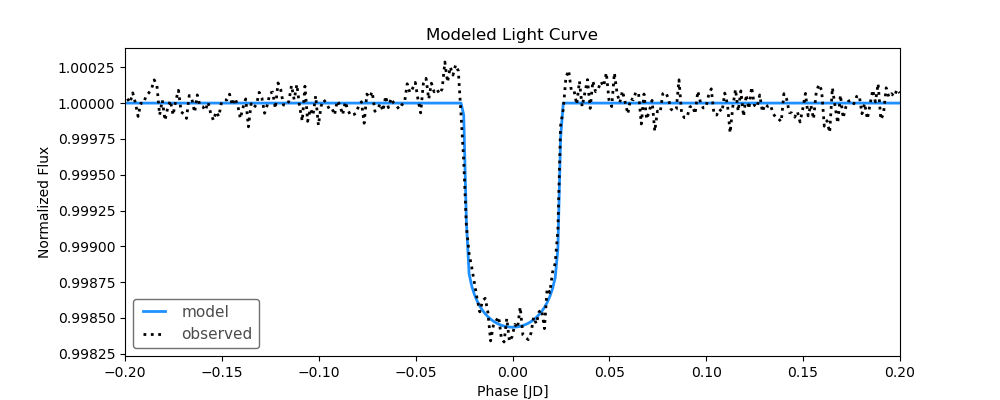

radius: 1.5062064928531003 earthRad
inclination: 88.41436260165949 deg
eccentricity: 9.102493770674423e-06
argument of periapsis (w): 90.57537150312362 deg


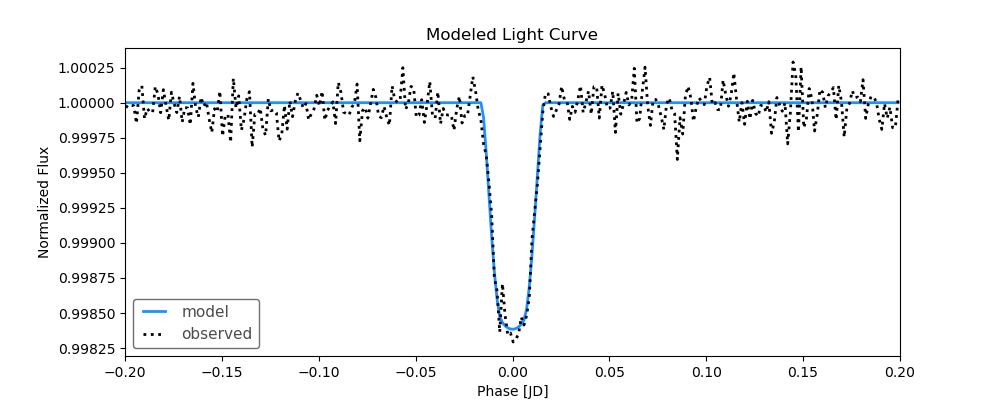

radius: 0.6600210470125111 earthRad
inclination: 89.99999759048366 deg
eccentricity: 4.958079931358179e-13
argument of periapsis (w): 90.0 deg


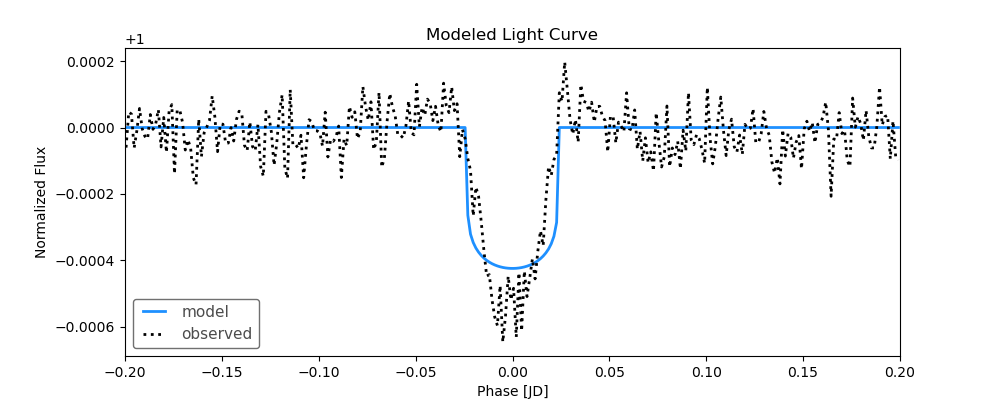

In [25]:
def initial_estimates(exoplanet, star):
    rad_est = (exoplanet['radius'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    inc_est = 90
    ecc_est = 0
    w_est = 90
    estimates = [rad_est, inc_est, ecc_est, w_est]
    lower_bounds = [rad_est-0.02,80,0,0]
    upper_bounds = [rad_est+0.02,90,0.999,180]
    return estimates, lower_bounds, upper_bounds
    
def batman_fun(x, exoplanet, star):
    params = batman.TransitParams()
    params.t0 = 0
    params.per = exoplanet['period'].value
    params.rp = x[0]
    params.a = (exoplanet['semimajor_axis'].to(u.Rsun))/(star['rad'][0]*u.Rsun)
    params.inc = x[1]
    params.ecc = x[2]
    params.w = x[3]
    params.limb_dark = 'nonlinear'
    params.u = [0.5,0.1,0.1,-0.1]  
    
    phase_min = min(exoplanet['light_curve'].phase.value)
    phase_max = max(exoplanet['light_curve'].phase.value)
    phase_len = len(exoplanet['light_curve'].flux.value)
    time = np.linspace(phase_min, phase_max, phase_len)
                       
    model = batman.TransitModel(params,time)
    batman_flux = model.light_curve(params)
    return batman_flux

def calc_residuals(x, exoplanet, star):
    observed = exoplanet['light_curve'].flux.value
    observed_error = exoplanet['light_curve'].flux_err.value
    modeled = batman_fun(x, exoplanet, star)
    
    residuals = (observed-modeled)/observed_error
    return residuals

def plot_model(each, star):
    batman_flux = batman_fun(results.x, each, star)
    phase = each['light_curve'].phase.value

    fig, ax = plt.subplots(figsize = (10,4))
    ax.plot(phase, batman_flux, linewidth = '2', color = 'dodgerblue', label = 'model')
    each['light_curve'].plot(ax = ax, linewidth = '2', linestyle = ':', color = 'black', label = 'observed')
    plt.title('Modeled Light Curve')
    plt.xlim(-0.2,0.2)
    plt.show()

for each in exoplanets:
    estimates, lower_bounds, upper_bounds = initial_estimates(each, star)
    results = least_squares(calc_residuals, estimates, bounds = (lower_bounds, upper_bounds), args = (each, star,))

    each['radius'] = (results.x[0]*star['rad'][0]*u.Rsun).to(u.Rearth)
    each['inclination'] = results.x[1]*u.degree
    each['eccentricity'] = results.x[2]
    each['arg_periapsis'] = results.x[3]*u.degree
    print(f'radius: {each['radius']}')
    print(f'inclination: {each['inclination']}')
    print(f'eccentricity: {each['eccentricity']}')
    print(f'argument of periapsis (w): {each['arg_periapsis']}')

    plot_model(each, star)

In [26]:
for each in exoplanets:
    b1 = ((each['semimajor_axis']*np.cos(each['inclination'].to(u.radian)))/((star['rad'][0]*u.Rsun).to(u.au)))
    b2 = ((1-np.square(each['eccentricity']))/(1+(np.square(each['eccentricity'])*np.sin(each['arg_periapsis'].to(u.radian)))))

    each['impact_parameter'] = b1*b2
    print(f'impact parameter: {round(each['impact_parameter'],4)}')

impact parameter: 0.4746
impact parameter: 0.939
impact parameter: 0.0


In [27]:
exoplanets

[{'period': <Quantity 3.69067699 d>,
  'duration': <Quantity 0.0442 d>,
  't0': <Time object: scale='tdb' format='btjd' value=2256.725904755244>,
  'depth': np.float64(0.0016675360912337123),
  'light_curve': <FoldedLightCurve length=288 LABEL="TIC 307210830" SECTOR=98 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
          time                flux               flux_err       ...       pos_corr1             pos_corr2       
                                                                ...          pix                   pix          
       TimeDelta            float64              float64        ...        float64               float64        
  -------------------- ------------------ --------------------- ... --------------------- ----------------------
  -0.19879521358556945 1.0000303284962495 7.291787402944332e-05 ...  0.004632186610251665 -0.0034752723295241594
  -0.19740632469668057 1.0000027079858724  7.29164042489004e-05 ...  0.004812395665794611 -0.0034635947085916996
  -0.1960174358

#### Ideas for improvement
- test false positives
- compare results with exoplanet archive
- map on distribution trends
- create output table
- add detection for longer periods
- transit timing variations
- bin just for model, replace current binned with get_transit_model